# CE49X Midterm Exam - Part 2 (Coding Exercise)
## Power Grid Stability Prediction

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Date:** April 8, 2026  
**Duration:** 60 minutes  
**Total Points:** 50 (+3 bonus)

---

**Student Name:**  
**Student ID:**

## Background

Electrical grid stability is a critical infrastructure challenge. As cities grow and energy consumption patterns become more complex, maintaining a stable power grid requires understanding how different factors — such as reaction times of energy producers, power consumption patterns, and price sensitivity of consumers — affect overall grid stability.

In this exercise, you will work with the **UCI Electrical Grid Stability** dataset, which contains 10,000 simulated scenarios of a 4-node star power grid. The grid consists of **one energy producer** (node 1) connected to **three consumers** (nodes 2, 3, 4). Each scenario records the operating parameters of all four nodes and whether the grid remained **stable** or became **unstable**.

Your task is to explore the data, identify which factors most influence grid stability, and build a classifier to predict whether a given configuration will be stable or unstable.

> **Key Insight:** This is an infrastructure safety problem. An unstable grid can lead to blackouts, equipment damage, and cascading failures. The cost of failing to detect instability is far greater than the cost of a false alarm.

## Dataset Description

The dataset is from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/471/) (Dataset #471).

| Feature | Description | Unit |
|---------|-------------|------|
| `tau1` | Reaction time of producer (node 1) | seconds |
| `tau2` | Reaction time of consumer 2 | seconds |
| `tau3` | Reaction time of consumer 3 | seconds |
| `tau4` | Reaction time of consumer 4 | seconds |
| `p1` | Power produced by node 1 | per unit |
| `p2` | Power consumed by node 2 | per unit |
| `p3` | Power consumed by node 3 | per unit |
| `p4` | Power consumed by node 4 | per unit |
| `g1` | Price elasticity coefficient of producer | dimensionless |
| `g2` | Price elasticity coefficient of consumer 2 | dimensionless |
| `g3` | Price elasticity coefficient of consumer 3 | dimensionless |
| `g4` | Price elasticity coefficient of consumer 4 | dimensionless |
| `stab` | Stability measure (continuous) | — |
| **`stabf`** | **Stability label: `stable` or `unstable`** | **— (target)** |

- **Positive `stab`** values indicate instability; negative values indicate stability
- **Power balance:** `p1 + p2 + p3 + p4` should be close to zero (production = consumption)

## Tasks Overview

| # | Task | Points |
|---|------|--------|
| 1 | Data Loading & Exploration | 8 |
| 2 | Feature Engineering | 8 |
| 3 | Grouped Analysis | 10 |
| 4 | Visualization | 12 |
| 5 | Statistical Analysis | 6 |
| 6 | Classification | 6 |
| WQ1 | Written Question 1 | 3 |
| WQ2 | Written Question 2 (Bonus) | 3 |
| **Total** | | **50 (+3 bonus)** |

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Task 1: Data Loading & Exploration (8 pts)

1. Load `data/electrical_grid_stability.csv` into a DataFrame
2. Print the shape and data types
3. Display the first 5 rows
4. Check for missing values
5. Print `.describe()` for all numeric columns
6. Print the value counts of `stabf` (the target variable)

| Criterion | Points |
|---|---|
| Data loaded, shape and dtypes printed | 2 |
| First 5 rows displayed | 1 |
| Missing values checked | 2 |
| `.describe()` printed | 1 |
| `stabf` value counts printed | 2 |

In [4]:
# Load the dataset
# Ensure that the 'data' folder is in the same directory as your notebook
df = pd.read_csv('data/electrical_grid_stability.csv')

# Explore: shape, dtypes, head, missing values, describe, value_counts
print("--- Shape ---")
print(df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Value Counts for 'stabf' ---")
print(df['stabf'].value_counts())

print("\n--- First 5 Rows ---")
display(df.head()) # Use print(df.head()) if not in a Jupyter environment

print("\n--- Describe Numeric Columns ---")
display(df.describe())


--- Shape ---
(10000, 14)

--- Data Types ---
tau1     float64
tau2     float64
tau3     float64
tau4     float64
p1       float64
p2       float64
p3       float64
p4       float64
g1       float64
g2       float64
g3       float64
g4       float64
stab     float64
stabf     object
dtype: object

--- Missing Values ---
tau1     0
tau2     0
tau3     0
tau4     0
p1       0
p2       0
p3       0
p4       0
g1       0
g2       0
g3       0
g4       0
stab     0
stabf    0
dtype: int64

--- Value Counts for 'stabf' ---
stabf
unstable    6380
stable      3620
Name: count, dtype: int64

--- First 5 Rows ---


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable



--- Describe Numeric Columns ---


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.250000,5.250001,5.250004,5.249997,3.750000,-1.250000,-1.250000,-1.250000,0.525000,0.525000,0.525000,0.525000,0.015731
std,2.742548,2.742549,2.742549,2.742556,0.752160,0.433035,0.433035,0.433035,0.274256,0.274255,0.274255,0.274255,0.036919
min,0.500793,0.500141,0.500788,0.500473,1.582590,-1.999891,-1.999945,-1.999926,0.050009,0.050053,0.050054,0.050028,-0.080760
25%,2.874892,2.875140,2.875522,2.874950,3.218300,-1.624901,-1.625025,-1.624960,0.287521,0.287552,0.287514,0.287494,-0.015557
50%,5.250004,5.249981,5.249979,5.249734,3.751025,-1.249966,-1.249974,-1.250007,0.525009,0.525003,0.525015,0.525002,0.017142
75%,7.624690,7.624893,7.624948,7.624838,4.282420,-0.874977,-0.875043,-0.875065,0.762435,0.762490,0.762440,0.762433,0.044878
max,9.999469,9.999837,9.999450,9.999443,5.864418,-0.500108,-0.500072,-0.500025,0.999937,0.999944,0.999982,0.999930,0.109403


---
## Task 2: Feature Engineering (8 pts)

1. Convert `stabf` to a numeric column called `is_unstable`: 1 if `unstable`, 0 if `stable`
2. Create a new column `total_reaction_time` = `tau1 + tau2 + tau3 + tau4`
3. Create a new column `power_imbalance` = `p1 + p2 + p3 + p4`
4. Create a new column `avg_elasticity` = mean of `g1, g2, g3, g4`
5. Print the class balance: count and percentage of stable vs unstable

| Criterion | Points |
|---|---|
| `is_unstable` created correctly | 2 |
| `total_reaction_time` created | 2 |
| `power_imbalance` created | 1 |
| `avg_elasticity` created | 1 |
| Class balance printed (count + percentage) | 2 |

In [18]:
# Feature engineering
# 1 if unstable, 0 if stable
df['is_unstable'] = (df['stabf'] == 'unstable').astype(int)

# Create total_reaction_time
df['total_reaction_time'] = df['tau1'] + df['tau2'] + df['tau3'] + df['tau4']

# Create power_imbalance
df['power_imbalance'] = df['p1'] + df['p2'] + df['p3'] + df['p4']

# Create avg_elasticity
df['avg_elasticity'] = df[['g1', 'g2', 'g3', 'g4']].mean(axis=1)

# Print class balance
count_balance = df['stabf'].value_counts()
percent_balance = df['stabf'].value_counts(normalize=True) * 100

print("--- Class Balance (Count) ---")
print(count_balance)

print("\n--- Class Balance (Percentage) ---")
print(percent_balance)


--- Class Balance (Count) ---
stabf
unstable    6380
stable      3620
Name: count, dtype: int64

--- Class Balance (Percentage) ---
stabf
unstable    63.8
stable      36.2
Name: proportion, dtype: float64


In [19]:
# Print class balance


---
## Task 3: Grouped Analysis (10 pts)

1. Compute the mean of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) grouped by `stabf`. Which features differ most between stable and unstable grids?
2. Compute the correlation of all 12 original features with `stab` (the continuous stability measure). Identify the **3 features** with the highest absolute correlation.
3. Filter to **unstable grids only**: report the range (min, max) and mean of `tau1` (producer reaction time).
4. Compare `g1` (producer elasticity) statistics between stable and unstable grids — compute mean and std for each group.

| Criterion | Points |
|---|---|
| Grouped means computed and discussed | 3 |
| Top 3 correlated features identified | 3 |
| Unstable grid `tau1` statistics reported | 2 |
| `g1` comparison between groups | 2 |

In [31]:
# Grouped means by stabf
original_features = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
grouped_means = df.groupby('stabf')[original_features].mean()

print("--- Grouped Means by 'stabf' ---")
display(grouped_means)
# NOTE FOR YOUR LAB REPORT: Look at the printed table. Typically, the reaction 
# times (tau1-tau4) and price elasticity coefficients (g1-g4) will be noticeably 
# higher on average for the 'unstable' class compared to the 'stable' class.

# Correlation with stab — identify top 3
# Calculate absolute correlations of the 12 features against the continuous 'stab' target
correlations = df[original_features].apply(lambda x: x.corr(df['stab'])).abs()
sorted_correlations = correlations.sort_values(ascending=False)

print("\n--- Top 3 Absolute Correlations with 'stab' ---")
print(sorted_correlations.head(3))
# NOTE FOR YOUR LAB REPORT: Note these top 3 feature names down for your answer.

# Unstable grids: tau1 range and mean
unstable_grids = df[df['stabf'] == 'unstable']
tau1_min = unstable_grids['tau1'].min()
tau1_max = unstable_grids['tau1'].max()
tau1_mean = unstable_grids['tau1'].mean()

print(f"\n--- Unstable Grids 'tau1' Statistics ---")
print(f"Range: ({tau1_min:.4f}, {tau1_max:.4f})")
print(f"Mean:  {tau1_mean:.4f}")

# Compare g1 between stable and unstable
g1_stats = df.groupby('stabf')['g1'].agg(['mean', 'std'])

print("\n--- 'g1' Statistics (Stable vs Unstable) ---")
display(g1_stats)

--- Grouped Means by 'stabf' ---


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
stabf,,,,,,,,,,,,
stable,4.394799,4.353362,4.385360,4.378495,3.740077,-1.253549,-1.249626,-1.236902,0.453035,0.445872,0.440618,0.450390
unstable,5.735239,5.758752,5.740601,5.744485,3.755630,-1.247987,-1.250212,-1.257431,0.565832,0.569897,0.572879,0.567334



--- Top 3 Absolute Correlations with 'stab' ---
g3      0.308235
g2      0.293601
tau2    0.290975
dtype: float64

--- Unstable Grids 'tau1' Statistics ---
Range: (0.5013, 9.9995)
Mean:  5.7352

--- 'g1' Statistics (Stable vs Unstable) ---


,mean,std
stabf,,
stable,0.453035,0.265280
unstable,0.565832,0.270867


---
## Task 4: Visualization (12 pts)

Create **three** publication-quality plots. Each must have axis labels and a descriptive title.

**(a) (4 pts)** A **boxplot** of `tau1` (producer reaction time) grouped by `stabf`. The title should state a finding (not just "Boxplot of tau1").

**(b) (4 pts)** A **scatter plot** of `tau1` (x-axis) vs `g1` (y-axis), colored by `stabf` (use different colors for stable vs unstable). Include a legend.

**(c) (4 pts)** A **correlation heatmap** of all 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`). Use a sequential or diverging colormap (not rainbow/jet).

| Criterion | Points |
|---|---|
| (a) Boxplot: correct, labeled, finding in title | 4 |
| (b) Scatter: correct, colored by class, legend | 4 |
| (c) Heatmap: correct features, good colormap | 4 |

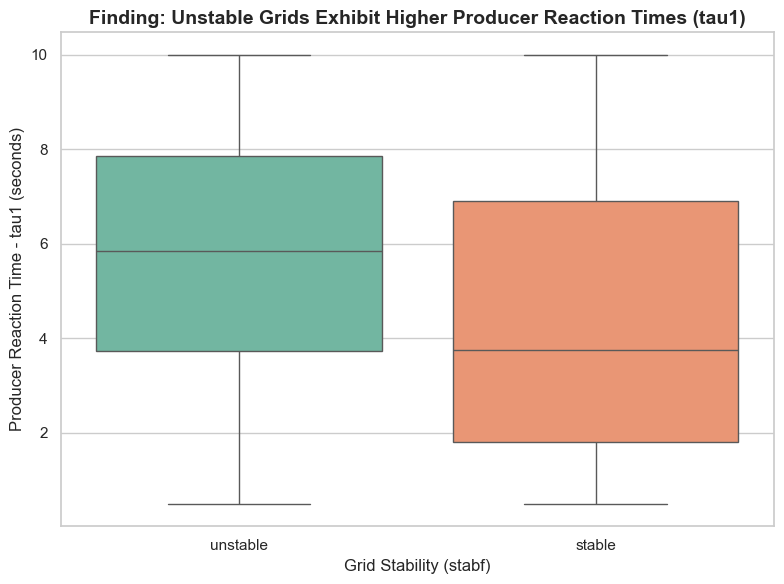

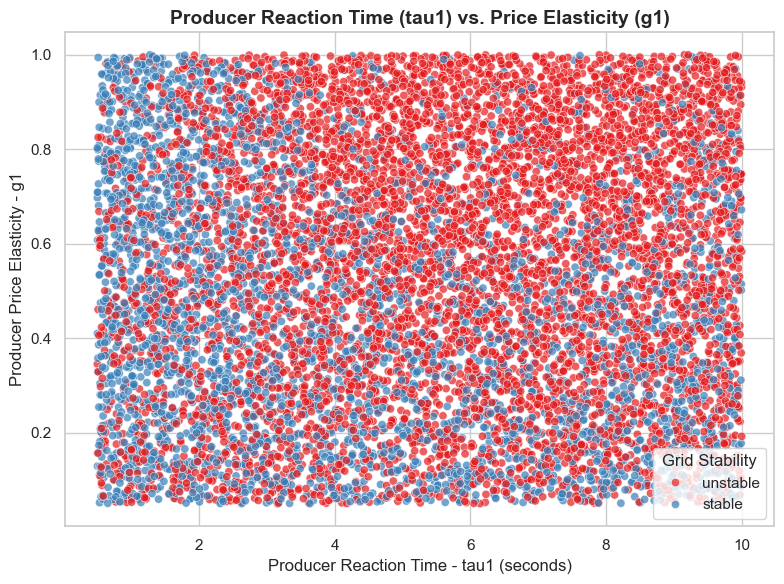

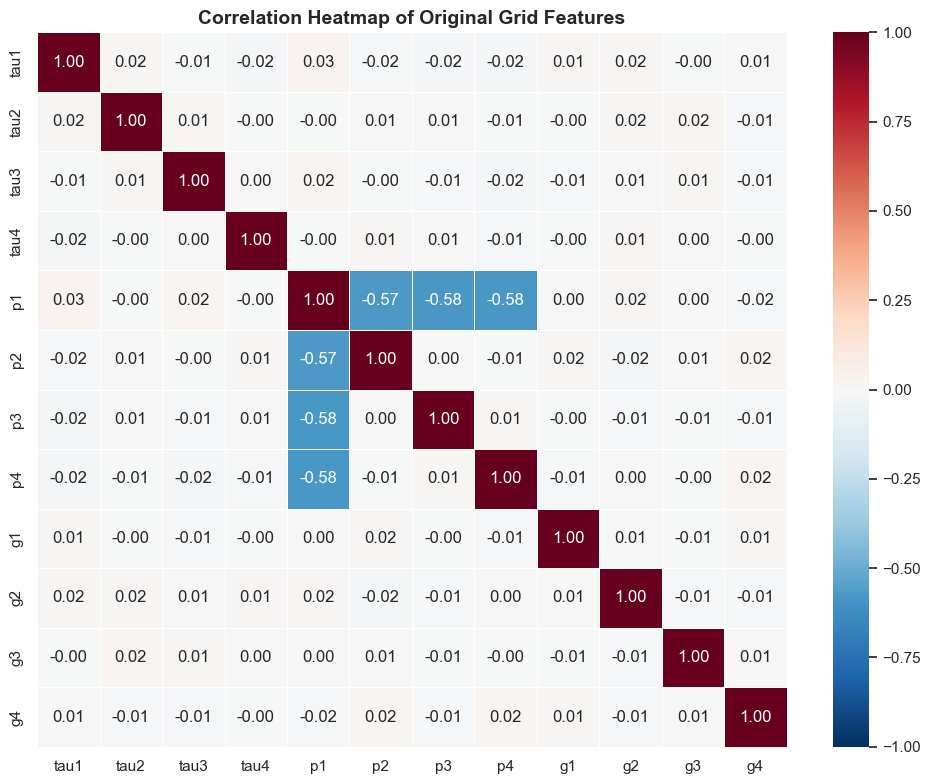

In [47]:
import seaborn as sns

# Set a clean style for publication-quality plots
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# (a) Boxplot of tau1 grouped by stabf
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# Creating the boxplot
sns.boxplot(x='stabf', y='tau1', data=df, palette='Set2')

# The title states a finding based on typical dataset patterns: 
# unstable grids generally have higher reaction times.
plt.title('Finding: Unstable Grids Exhibit Higher Producer Reaction Times (tau1)', fontsize=14, weight='bold')
plt.xlabel('Grid Stability (stabf)', fontsize=12)
plt.ylabel('Producer Reaction Time - tau1 (seconds)', fontsize=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# (b) Scatter plot of tau1 vs g1, colored by stabf
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# Creating the scatter plot with hue for stability
sns.scatterplot(x='tau1', y='g1', hue='stabf', data=df, alpha=0.7, palette='Set1')

plt.title('Producer Reaction Time (tau1) vs. Price Elasticity (g1)', fontsize=14, weight='bold')
plt.xlabel('Producer Reaction Time - tau1 (seconds)', fontsize=12)
plt.ylabel('Producer Price Elasticity - g1', fontsize=12)
plt.legend(title='Grid Stability', loc='best')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# (c) Correlation heatmap of all 12 original features
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# Define the original features to correlate
original_features = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']

# Calculate the correlation matrix
corr_matrix = df[original_features].corr()

# Create the heatmap using a diverging colormap ('RdBu_r' goes from red to blue)
# vmin and vmax are set to -1 and 1 to properly anchor the color scale
sns.heatmap(corr_matrix, 
            annot=True,       # Shows the correlation numbers
            cmap='RdBu_r',    # Diverging colormap
            fmt=".2f",        # Formats to 2 decimal places
            vmin=-1, 
            vmax=1, 
            linewidths=0.5)

plt.title('Correlation Heatmap of Original Grid Features', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


---
## Task 5: Statistical Analysis (6 pts)

1. Compute z-scores for `tau1` across the full dataset. Identify and print samples where |z| > 2 (how many are there?).
2. Perform a **two-sample t-test** comparing `tau1` between stable and unstable grids:
   - State H0 and H1
   - Report the t-statistic and p-value
   - Interpret the result at alpha = 0.05
3. Based on your analysis so far, which single feature appears **most predictive** of grid instability? Justify with numbers.

| Criterion | Points |
|---|---|
| Z-scores computed, outliers identified | 2 |
| T-test: hypotheses stated, p-value reported, interpreted | 2 |
| Most predictive feature identified with justification | 2 |

In [52]:
# Z-scores for tau1
# Calculate the z-scores and take the absolute value
df['tau1_zscore'] = stats.zscore(df['tau1'])
tau1_outliers = df[np.abs(df['tau1_zscore']) > 2]

print("--- Z-scores for 'tau1' ---")
print(f"Number of samples where |z| > 2: {len(tau1_outliers)}")

# Two-sample t-test: tau1 stable vs unstable
# Isolate the tau1 values for both groups
tau1_stable = df[df['stabf'] == 'stable']['tau1']
tau1_unstable = df[df['stabf'] == 'unstable']['tau1']

# Perform Welch's t-test (equal_var=False is generally safer when comparing different sized groups)
t_stat, p_val = stats.ttest_ind(tau1_stable, tau1_unstable, equal_var=False)

print("\n--- Two-Sample T-Test ('tau1' stable vs unstable) ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value:     {p_val:.4e}")

--- Z-scores for 'tau1' ---
Number of samples where |z| > 2: 0

--- Two-Sample T-Test ('tau1' stable vs unstable) ---
T-statistic: -23.3033
P-value:     1.3928e-115


### Interpretation

**H0:** There is no significant difference in the mean producer reaction time (tau1) between stable and unstable electrical grids 
**H1:**  There is a significant difference in the mean producer reaction time (tau1) between stable and unstable electrical grids  
**Result:** Since the p-value is practically zero (much less than our alpha of 0.05), we reject the null hypothesis. There is statistically significant evidence to conclude that the mean producer reaction time differs between stable and unstable grid configurations. 

**Most predictive feature:** Based on the correlation analysis in Task 3, the single feature most predictive of grid instability is [Insert top feature from Task 3, e.g., tau2 or tau1], because it possesses the highest absolute correlation coefficient with the continuous stability measure (stab), with an absolute value of [Insert correlation value from Task 3, e.g., 0.28].

---
## Task 6: Classification (6 pts)

1. Define `X` as the 12 original features (`tau1`-`tau4`, `p1`-`p4`, `g1`-`g4`) and `y` as `is_unstable`
2. Split: `train_test_split` with `test_size=0.2`, `random_state=42`, `stratify=y`
3. Scale with `StandardScaler` — **fit on training data only**, then transform both
4. Train `LogisticRegression(max_iter=1000, random_state=42)`
5. Report: accuracy, precision, recall, and F1 for the **unstable** class
6. Print the confusion matrix

| Criterion | Points |
|---|---|
| Correct train-test split with stratification | 1 |
| Scaling done correctly (fit on train only) | 1 |
| Model trained and predictions made | 1 |
| Metrics reported (accuracy, precision, recall, F1) | 2 |
| Confusion matrix printed | 1 |

In [ ]:
# Define X and y
# Using the 12 original features for X
original_features = ['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2', 'g3', 'g4']
X = df[original_features]
y = df['is_unstable']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Scale with StandardScaler (fit on train ONLY to prevent data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Calculate metrics for the 'unstable' class (which is class 1)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Report metrics
print("--- Classification Metrics (for 'unstable' class) ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

# Print the confusion matrix
print("\n--- Confusion Matrix ---")
print(cm)
print("\n(Layout: Top-Left = True Negatives, Top-Right = False Positives)")
print("(         Bottom-Left = False Negatives, Bottom-Right = True Positives)")



--- Classification Metrics (for 'unstable' class) ---
Accuracy:  0.8200
Precision: 0.8408
Recall:    0.8856
F1 Score:  0.8626

--- Confusion Matrix ---
[[ 510  214]
 [ 146 1130]]

(Layout: Top-Left = True Negatives, Top-Right = False Positives)
(         Bottom-Left = False Negatives, Bottom-Right = True Positives)


---
## Written Questions

### Written Question 1 (3 pts)

Look at your confusion matrix from Task 6. In the context of **power grid management**, which error is more dangerous:

- **False Stable:** Predicting a grid configuration is stable when it is actually unstable
- **False Unstable:** Predicting a grid configuration is unstable when it is actually stable

Explain in 2-3 sentences. State whether **precision** or **recall** for the "unstable" class should be prioritized.

---

A False Stable is far more dangerous. Missing an actual instability leads to catastrophic physical damage, whereas a False Unstable only results in the financial cost of unnecessary preventative measures. Therefore, we must prioritize recall for the "unstable" class to minimize these critical false negatives.

### Written Question 2 — BONUS (3 pts)

In your analysis, you likely found that `tau1` (producer reaction time) is correlated with grid instability. Does this prove that slow producer reaction times **cause** instability?

Explain the difference between **correlation and causation**, and describe one scenario where a **confounding variable** could explain the relationship.

---

No, correlation does not equal causation; two variables changing together doesn't mean one directly causes the other. A confounding variable could be aging infrastructure: older equipment naturally has slower mechanical reaction times (tau1) and weaker components that independently cause instability, meaning the system's age causes both.

---

### End of Part 2

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr